# Experiments with self-calibrating readouts and other-calibrating readouts

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.core.pylabtools import figsize

import seaborn as sns

import numpy as np
import pandas as pd

from tqdm import tqdm
import torch

from ipywidgets import interact, IntSlider

## Building intuition for losses w/ and w/o softmax

In [109]:
outs = torch.randn(64, 100)
def sm_outs(T):
    return torch.softmax(outs / T, dim=1)

self_calibration_loss = torch.nn.CrossEntropyLoss()

Text(0.5, 0, 'Temperature')

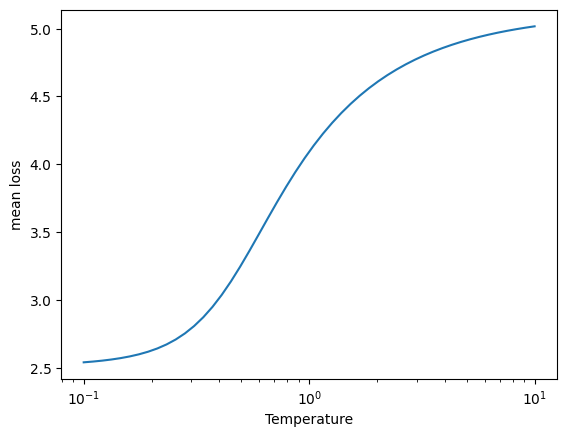

In [107]:
Ts = np.logspace(-1, 1)
losses = [ self_calibration_loss(outs, sm_outs(T)).item() for T in Ts]

plt.semilogx(Ts, losses)
plt.ylabel('mean loss')
plt.xlabel('Temperature')

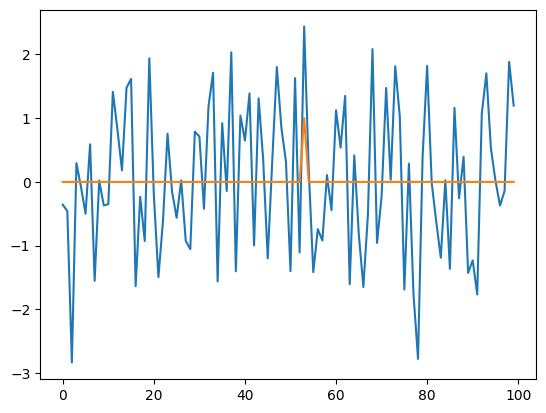

In [128]:
plt.plot(outs[0])
plt.plot(sm_outs(0.01)[0])

This is not what I was expecting. I thought that the loss would peak a temperature 1, where the SM normally resides. Instead, it favors low temperatures = more concentrated distributions...

This result is robust to re-sampling

In [ ]:
outs = torch.randn(64, 100)
def sm_outs(T):
    return torch.softmax(outs / T, dim=1)

self_calibration_loss = torch.nn.CrossEntropyLoss()

Text(0.5, 0, 'Temperature')

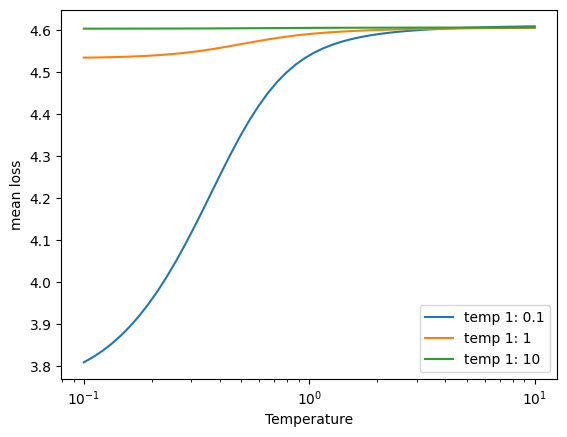

In [126]:
Ts = np.logspace(-1, 1)

for T1 in [0.1, 1, 10]:
    losses = [ self_calibration_loss(sm_outs(T1), sm_outs(T)).item() for T in Ts]
    
    plt.semilogx(Ts, losses, label=f'temp 1: {T1}')

plt.legend()
plt.ylabel('mean loss')
plt.xlabel('Temperature')

Changing to comparing soft-max to soft-max: the trend is the same: lower temperature, lower loss. This applies to both temperatures: changing the temperature of the first soft-max amounts to a decrease in the slope but no change in the trend (hard to see, but just plot this one solo).

Aha. 
- Temperature of the second entry T large -> uniform baseline prob -> high entropy baseline in targets
- Temperature of the first entry T large -> predictions uniform -> worse than less uniform, accurate predictions


#### What if we average first vs averaging second?

In [138]:
outs = torch.randn(64, 50, 100)
def sm_outs(T):
    return torch.softmax(outs / T, dim=2)

self_calibration_loss = torch.nn.CrossEntropyLoss()

Text(0.5, 0, 'Temperature')

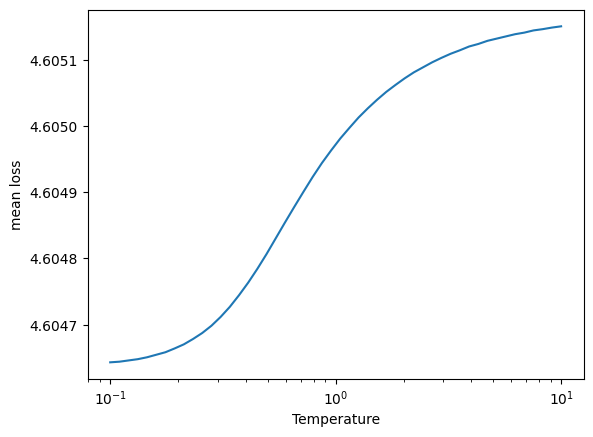

In [141]:
Ts = np.logspace(-1, 1)
losses = [ self_calibration_loss(torch.softmax(outs.mean(1), dim=1), sm_outs(T).mean(1)).item() for T in Ts]

plt.semilogx(Ts, losses)
plt.ylabel('mean loss')
plt.xlabel('Temperature')

Same trend

In [153]:
torch.softmax(outs.mean(1), dim=1)

tensor([[0.0089, 0.0078, 0.0117,  ..., 0.0091, 0.0107, 0.0100],
        [0.0113, 0.0103, 0.0086,  ..., 0.0107, 0.0100, 0.0095],
        [0.0102, 0.0114, 0.0110,  ..., 0.0104, 0.0089, 0.0084],
        ...,
        [0.0096, 0.0109, 0.0093,  ..., 0.0107, 0.0090, 0.0108],
        [0.0098, 0.0103, 0.0122,  ..., 0.0100, 0.0108, 0.0096],
        [0.0093, 0.0075, 0.0136,  ..., 0.0092, 0.0102, 0.0107]])

In [154]:
torch.softmax(outs, dim=2).mean(1)

tensor([[0.0094, 0.0078, 0.0101,  ..., 0.0086, 0.0093, 0.0098],
        [0.0099, 0.0096, 0.0083,  ..., 0.0116, 0.0112, 0.0106],
        [0.0103, 0.0134, 0.0102,  ..., 0.0120, 0.0090, 0.0092],
        ...,
        [0.0110, 0.0109, 0.0097,  ..., 0.0096, 0.0094, 0.0097],
        [0.0102, 0.0101, 0.0189,  ..., 0.0097, 0.0105, 0.0095],
        [0.0086, 0.0072, 0.0123,  ..., 0.0084, 0.0102, 0.0101]])

I thought that these would be the same... but they're not. I guess there was really no reason to think that...

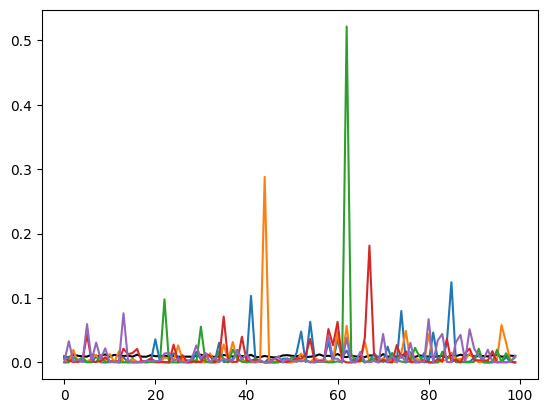

In [159]:
plt.plot(torch.softmax(outs.mean(1), dim=1)[0], 'k')
for i in range(5):
    plt.plot(torch.softmax(outs/0.5, dim=2)[0,i,:])

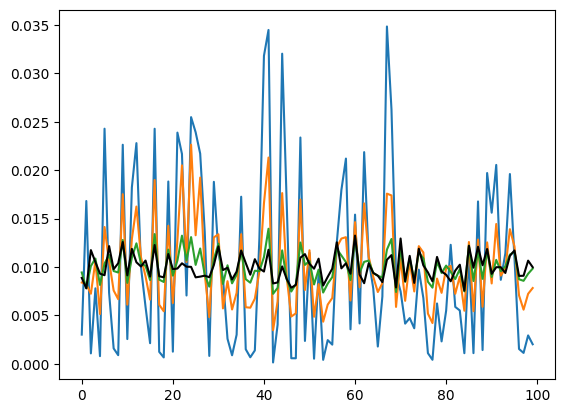

In [194]:
plt.plot(torch.softmax(outs/0.2, dim=2).mean(1)[0])
plt.plot(torch.softmax(outs/0.5, dim=2).mean(1)[0])
plt.plot(torch.softmax(outs/1, dim=2).mean(1)[0])

plt.plot(torch.softmax(outs.mean(1), dim=1)[0], 'k')

This looks opposite (?) low temps -> concentrated distributions -> noisy averages.

In [175]:
self_calibration_loss = torch.nn.CrossEntropyLoss()
i = 30
for T in [0.2, 0.5, 1]:
    print(T, self_calibration_loss(torch.softmax(outs.mean(1), dim=1)[i],
                                   torch.softmax(outs/T, dim=2).mean(1)[i]))

0.2 tensor(4.6046)

0.5 tensor(4.6048)

1 tensor(4.6050)

Huh. Slight increases in loss as temperature increases. Fairly consistent across samples, interestingly...

I think that the constancy across samples is a result of the purely random data, which get very close to uniform on averaging + softmax

### Entropy, KL divergence, Cross-entropy

Cross entropy is sum of KL diverence and entropy. Lets make sure that we have the direction correct.

#### Double check that the measurements that we are using

In [460]:
# working equivalence

import torch
import torch.nn.functional as F
from torch.distributions import Categorical

# 1. Use 2D tensors (Batch Size = 1, Classes = 100)
test1 = torch.randn(1, 100)
test2 = torch.randn(1, 100)

probs_p = torch.softmax(test1, dim=-1)

# 2. Cross Entropy (Pass RAW logits here, not log_probs)
# PyTorch CrossEntropy handles the log_softmax internally
ce_val = F.cross_entropy(test2, probs_p, reduction='mean')

# 3. KL Divergence (Requires log_probs for the first argument)
logits_q = F.log_softmax(test2, dim=-1)
# Using 'sum' to match the ce_val reduction
d_kl = F.kl_div(logits_q, probs_p, reduction='batchmean')

# 4. Entropy
h_p = Categorical(probs=probs_p).entropy().mean()

print(f'CE:        {ce_val.item():.4f}')
print(f'Combined:  {(h_p + d_kl).item():.4f}')

CE:        5.1238

Combined:  5.1238

In [461]:
loss = torch.nn.CrossEntropyLoss(reduction='mean')

loss(test2, torch.softmax(test1, dim=-1))

tensor(5.1238)

In [462]:
def cross_entropy(x, y):
    return F.cross_entropy(F.log_softmax(x, dim=-1), torch.softmax(y, dim=-1), reduction='mean')

def D_kl(x, y):
    return F.kl_div(F.log_softmax(x, dim=-1), torch.softmax(y, dim=-1), reduction='batchmean')

def H(x):
    return Categorical(probs=torch.softmax(x, dim=-1)).entropy().mean()

In [463]:
cross_entropy(test2, test1)

tensor(5.1238)

In [464]:
D_kl(test2, test1) + H(test1)

tensor(5.1238)

The order here is important: entropy of second arg + KL div first arg to second arg

We also have to be very careful about using logits vs probabilities.

In [465]:
def cross_entropy_probs(x, y):
    return F.cross_entropy(torch.log(x), y, reduction='mean')

def D_kl_probs(x, y):
    return F.kl_div(torch.log(x), y, reduction='batchmean')

def H_prob(x):
    return Categorical(probs=x).entropy().mean()

In [466]:
p1 = torch.softmax(test1, dim=1)
p2 = torch.softmax(test2, dim=1)

In [476]:
cross_entropy_probs(p2, p1)

tensor(5.1238)

In [477]:
D_kl_probs(p2, p1) + H_prob(p1)

tensor(5.1238)

#### Comparing contributions from different parts of the loss function

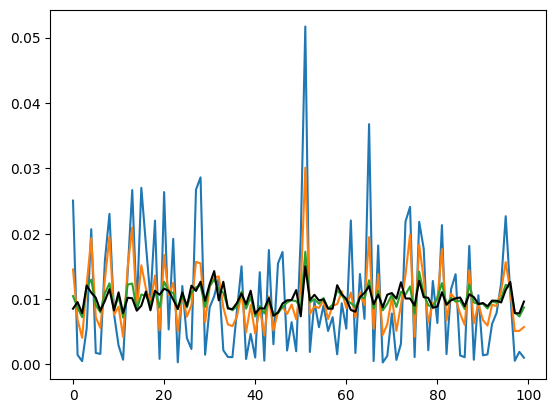

In [469]:
outs = torch.randn(64, 50, 100)

plt.plot(torch.softmax(outs/0.2, dim=2).mean(1)[0])
plt.plot(torch.softmax(outs/0.5, dim=2).mean(1)[0])
plt.plot(torch.softmax(outs/1, dim=2).mean(1)[0])

plt.plot(torch.softmax(outs.mean(1), dim=1)[0], 'k')

In [507]:
mean_of_sm0 = torch.softmax(outs/0.2, dim=2).mean(1)[0:1]
mean_of_sm1 = torch.softmax(outs/0.5, dim=2).mean(1)[0:1]
mean_of_sm2 = torch.softmax(outs/1, dim=2).mean(1)[0:1]

sm_of_mean = torch.softmax(outs.mean(1), dim=1)[0:1]

constant = torch.ones(100)/100.


print(f'CE: {cross_entropy_probs(sm_of_mean, mean_of_sm0)}, KL: {D_kl_probs(sm_of_mean, mean_of_sm0)}, Entropy: {H_prob(mean_of_sm0)}, sum: {D_kl_probs(sm_of_mean, mean_of_sm0) + H_prob(mean_of_sm0)}')
print(f'CE: {cross_entropy_probs(sm_of_mean, mean_of_sm1)}, KL: {D_kl_probs(sm_of_mean, mean_of_sm1)}, Entropy: {H_prob(mean_of_sm1)}, sum: {D_kl_probs(sm_of_mean, mean_of_sm1) + H_prob(mean_of_sm1)}')
print(f'CE: {cross_entropy_probs(sm_of_mean, mean_of_sm2)}, KL: {D_kl_probs(sm_of_mean, mean_of_sm2)}, Entropy: {H_prob(mean_of_sm2)}, sum: {D_kl_probs(sm_of_mean, mean_of_sm2) + H_prob(sm_of_mean)}')

CE: 4.5626630783081055, KL: 0.4021352231502533, Entropy: 4.160528182983398, sum: 4.562663555145264

CE: 4.57823371887207, KL: 0.06486783921718597, Entropy: 4.513365745544434, sum: 4.57823371887207

CE: 4.595525741577148, KL: 0.0041199736297130585, Entropy: 4.591405868530273, sum: 4.598515510559082

I'll note again how finicky these are. Gotta triple check that I'm doing what I think I'm doing.

In [513]:
def mean_of_sm_T(T):
    return torch.softmax(outs/T, dim=2).mean(1)

sm_of_mean = torch.softmax(outs.mean(1), dim=1)

In [521]:
CEs = []
KLs = []
Hs = []
Ts = np.logspace(-1, 1)

for T in Ts:
    mean_of_sm = mean_of_sm_T(T)[0:1]

    CEs.append(cross_entropy_probs(sm_of_mean[0:1], mean_of_sm) )
    KLs.append(D_kl_probs(sm_of_mean[0:1], mean_of_sm))
    Hs.append(H_prob(mean_of_sm))

    

In [522]:
np.array(CEs) - np.array(KLs) - np.array(Hs)

array([-2.3841858e-07, -2.3841858e-07,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  4.7683716e-07,  0.0000000e+00,  0.0000000e+00,
        4.7683716e-07,  4.7683716e-07,  0.0000000e+00,  4.7683716e-07,
        0.0000000e+00,  4.7683716e-07,  4.7683716e-07,  0.0000000e+00,
        0.0000000e+00, -4.7683716e-07,  0.0000000e+00,  4.7683716e-07,
       -4.7683716e-07,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00, -4.7683716e-07, -4.7683716e-07,
        4.7683716e-07, -9.5367432e-07,  0.0000000e+00, -4.7683716e-07,
       -4.7683716e-07,  0.0000000e+00,  4.7683716e-07, -4.7683716e-07,
       -4.7683716e-07,  0.0000000e+00, -9.5367432e-07,  4.7683716e-07,
        0.0000000e+00,  0.0000000e+00, -4.7683716e-07,  4.7683716e-07,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  4.7683716e-07,
        0.0000000e+00, -4.7683716e-07], dtype=float32)

Text(0.5, 1.0, 'Cross entropy')

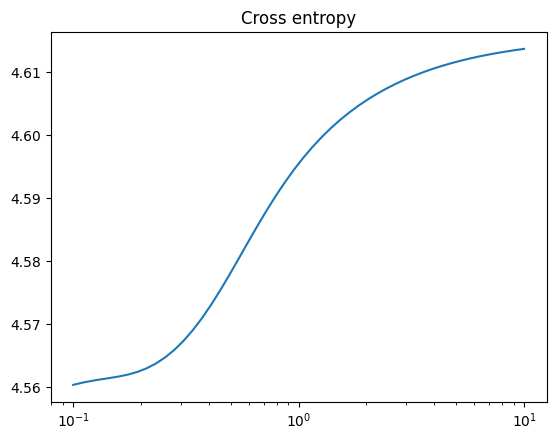

In [527]:
plt.semilogx(Ts, CEs)
plt.title('Cross entropy')

Text(0.5, 1.0, 'KL - Divergence')

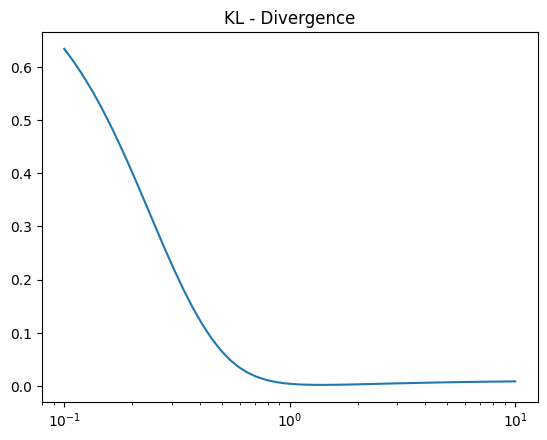

In [530]:
plt.semilogx(Ts, KLs)
plt.title('KL - Divergence')

Text(0.5, 1.0, 'Base entropy')

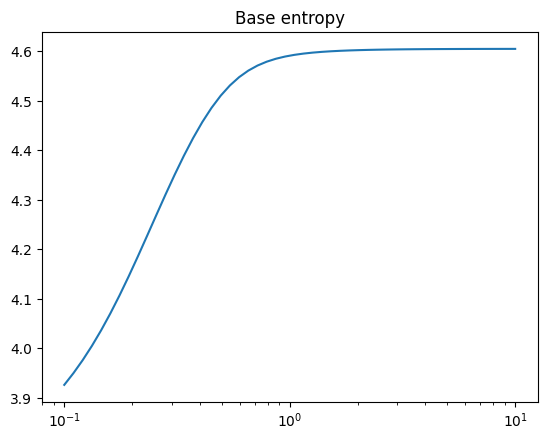

In [529]:
plt.semilogx(Ts, Hs)
plt.title('Base entropy')

This illuminates what is happening here: the cross entropy is dominated by the entropy that _increases_ with temperature. KL divergence _decreases_ with temperature.

The 'spikier-looking' plots I earlier interpreted as higher entropy, but this is incorrect: they are more concentrated = lower entropy.

I think we want just the KL divergence.

#### What direction of KL do we want?

In [531]:
def D_kl_probs(x, y):
    return F.kl_div(torch.log(x), y, reduction='batchmean')

In [545]:
x = torch.zeros(100)
x[10] = 0.1
x[30] = 0.9

y = torch.randn(100)
y[10] += 1
y[30] += 2
y = torch.softmax(y, dim=-1)

In [549]:
print(D_kl_probs(y, x))
print(D_kl_probs(x, y))

tensor(0.0238)

tensor(inf)

This is the _reverse_ of the traditional ordering.
$$D_{KL}(p | q) = \sum p(x) \log \frac{p(x)}{q(x)}$$

Is well behaved when $p(x) \to 0$ because the zero probability, but not when $q \to 0$. The support of q must be a contain of the support of p. q is never zero where x is zero.



In [564]:
# double check against the built in KLdiv loss

kl2 = torch.nn.KLDivLoss()
print('probability: ', D_kl_probs(y,x))
print('builtin: ', kl2(torch.log(y), x))

probability:  tensor(0.0238)

builtin:  tensor(0.0238)

### KL divergence for individual parts of the mixture

In [18]:
x = torch.zeros(100)
x[10] = 0.1
x[30] = 0.9

y = torch.randn(100)
y[10] += 1
y[30] += 2
y = torch.softmax(y, dim=-1)

In [21]:
import torch.nn.functional as F

def D_kl_probs(x, y):
    return F.kl_div(torch.log(x), y, reduction='batchmean')

In [23]:
D_kl_probs(y, x)

tensor(0.0165)

In [24]:
x1 = torch.zeros(100)
x1[10] = 1

x2 = torch.zeros(100)
x2[30] = 1


In [25]:
0.1*D_kl_probs(y, x1) + 0.9 * D_kl_probs(y, x2) 

tensor(0.0197)

#### How is it possible to get +- infinity from the KL divergence?

I suspect that this is due to round-off error in the first term.

In [13]:
self_calibration_loss = torch.nn.KLDivLoss(reduction='batchmean')

In [67]:
x1 = torch.zeros(100) - 1E-32
x1[10] = 1

x1 = x1.clamp(1E-32)

In [68]:
y = torch.randn(100)
y[10] += 1
y[30] += 2


In [69]:
self_calibration_loss(torch.log_softmax(y, dim=-1),
                      x1)

tensor(0.0460)

## Training runs: do the outputs maintain a degree of variation?

- many samples causes significant memory usage can get around this with torch checkpoints, which recompute the activitys during the backward pass.

1. My first stab at self-calibrating readouts fail: it diverges. There are a couple of explanations:
    - We are training both sides of the KL divergence -> instability
    - The softmax -> instability
    - KL direction - I'm using the soft-max outputs as target and training on these. -> instability.

2. Calibration readout on a pre-trained model:
    - getting NaN divergences with: 'backward KL', temperature 0.1
    - Most of an epoch with: 'backward KL', temperature 1.0, but it did go to NaN at the end.
    - MSE loss in logit space temp 0.2: No NaN. Trains well initially, but blows up at the end.
      
3. Bugs:
    - Gradient routing: I wasn't turning the gradients off properly: slows but doesn't fix the gradient blowup.
    - Classifier was unfrozen - there was some training of both sides of the KL divergence happening.
      
4. Working notes:
    - The step before losses go to NaN, the minimum output hits 0 exactly. In this same step the infinty norm hits - infinity. It certainly appears that this is causing the blow-up: the sample outputs are putting exactly zero weight where the target has non-zero weight.
    - I find this odd, note that this differs from cross-entropy, which intentionally does not compute those terms



In [2]:
from src.model.CLS_token_probing import SelfCalibratingReadout
from src.model.setup import image_model_setup

model_name = "facebook/dinov2-base"
dataset_name = "temp_dataset_subsample"

model, image_datasets, _ = image_model_setup(model_name, dataset_name, 1000)


W0302 10:53:45.985000 50260 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#### training a baseline that actually decodes class identity well.

In [ ]:
model.freeze_backbone(freeze_classifier=False)

from src.train.training import train_readout

dl_train = torch.utils.data.DataLoader(image_datasets['train'], batch_size=64, num_workers=1)
dl_val = torch.utils.data.DataLoader(image_datasets['validation'], batch_size=64, num_workers=1)

train_readout(model, dl_train, dl_val, 'baseline_readout')

#### training the readout

### MSE objective in log space

#### Investigating MSE loss readouts: why did they blow up?

In [3]:
model.train_cfg.readout_loss_weight = 1.0

In [4]:
from src.train.training import train_readout

dl_train = torch.utils.data.DataLoader(image_datasets['train'], batch_size=64, num_workers=1)
dl_val = torch.utils.data.DataLoader(image_datasets['validation'], batch_size=64, num_workers=1)

In [5]:
from safetensors import safe_open
raw = safe_open('baseline_readout/readout/model.safetensors', framework='pt')
model.model.load_state_dict({key: raw.get_tensor(key) for key in raw.keys()}, strict=False )

_IncompatibleKeys(missing_keys=['dinov2.embeddings.cls_token', 'dinov2.embeddings.mask_token', 'dinov2.embeddings.position_embeddings', 'dinov2.embeddings.patch_embeddings.projection.weight', 'dinov2.embeddings.patch_embeddings.projection.bias', 'dinov2.encoder.layer.0.norm1.weight', 'dinov2.encoder.layer.0.norm1.bias', 'dinov2.encoder.layer.0.attention.attention.query.weight', 'dinov2.encoder.layer.0.attention.attention.query.bias', 'dinov2.encoder.layer.0.attention.attention.key.weight', 'dinov2.encoder.layer.0.attention.attention.key.bias', 'dinov2.encoder.layer.0.attention.attention.value.weight', 'dinov2.encoder.layer.0.attention.attention.value.bias', 'dinov2.encoder.layer.0.attention.output.dense.weight', 'dinov2.encoder.layer.0.attention.output.dense.bias', 'dinov2.encoder.layer.0.layer_scale1.lambda1', 'dinov2.encoder.layer.0.norm2.weight', 'dinov2.encoder.layer.0.norm2.bias', 'dinov2.encoder.layer.0.mlp.fc1.weight', 'dinov2.encoder.layer.0.mlp.fc1.bias', 'dinov2.encoder.layer

In [6]:
from src.model.CLS_token_probing import SecondaryReadouts
readout = SecondaryReadouts.from_pretrained('static_target/readout/', layer_ind=11, temperature=0.2, num_samples=10)

readout.to('mps')
model.add_readout(readout, )
_=model.to('mps')

Loading weights from local directory


In [7]:
batch=next(iter(dl_val))

W0227 09:56:06.427000 24674 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


In [8]:
main_outs = model.model.forward(batch['input'].to('mps'), output_hidden_states=True)
model_outs = main_outs.logits.detach().cpu()

In [9]:
loss, readouts = readout.forward(main_outs)
readouts = readouts.detach().cpu()

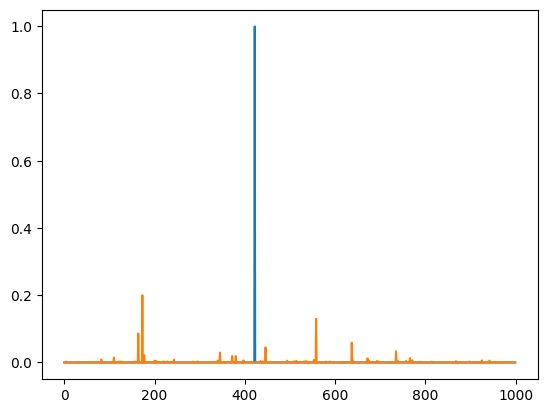

In [10]:
i = 12
plt.plot(torch.softmax(model_outs[i], dim=-1))
plt.plot(torch.softmax(readouts[i], dim=-1))

Indeed, these outputs have little to do with each other. How did this loss 'blow-up' happen?

In [11]:
model_input = main_outs.hidden_states[readout.layer_ind]
with torch.no_grad():
    sampled_readouts = torch.stack([readout.decoder.forward(model_input, readout.base_layer)
                                    for i in range(readout.num_samples)]).detach().cpu()

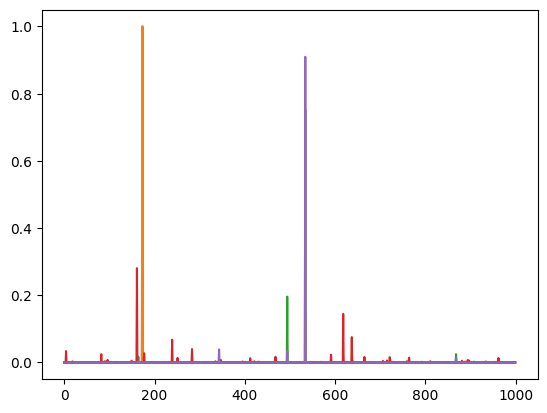

In [19]:
plt.plot(torch.softmax(sampled_readouts[0,i], dim=-1))
plt.plot(torch.softmax(sampled_readouts[1,i], dim=-1))
plt.plot(torch.softmax(sampled_readouts[2,i], dim=-1))
plt.plot(torch.softmax(sampled_readouts[3,i], dim=-1))
plt.plot(torch.softmax(sampled_readouts[4,i], dim=-1))

In [20]:
log_softmaxes = torch.log_softmax(sampled_readouts, dim=-1)

In [21]:
log_mixture = torch.logsumexp(log_softmaxes, dim=0) - torch.log(torch.tensor(readout.num_samples))

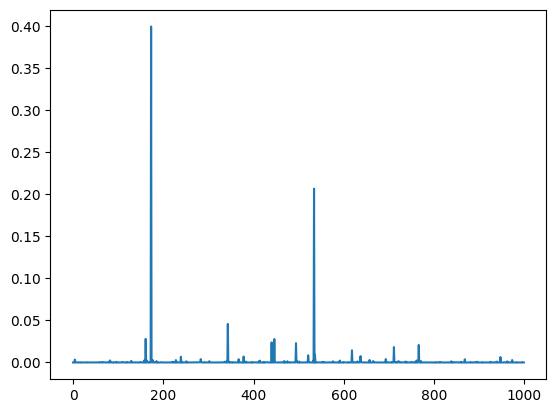

In [22]:
plt.plot(torch.softmax(log_mixture[i], dim=-1))

The learned solution _do_ keep their stochasticity between samples (I know the fit is bad, but I'll still analyze what was learned).


#### About the divergence:

I hypothesize that this was the result of the sampling noise, which causes random fluctuations in the gradients, which are, in turn fixed in place by the Adam optimizer. Thus, sampling -> instability regardless of objective, and that is the core problem that we need to address
Evidence:
- sudden, irrecoverable explosion or divergence
- seems to arise at random times, appears quicker for 10 


To dos:
- gradient clipping on individual values vs norm
- develop metrics to detect this divergence



### KL divergence

While debugging, I fixed several issues with gradient flow and an unfreezing classifier. I clamped the softmax probabilities to $10^{-30}$. Some success so far.

- with scheduler, 20 samples, gradients _vanish_ with large learning rate.
- no vanishing with normal learning rate scheduling

- 20 samples: low temperature (0.2) struggles to learn (max 42% shared mass, 26% validation accuracy). Temperature annealing 1 -> 0.2 learns much better (max 72% shared mass, 59% validation accuracy)


In [3]:
from src.train.training import train_readout

dl_train = torch.utils.data.DataLoader(image_datasets['train'], batch_size=64, num_workers=1)
dl_val = torch.utils.data.DataLoader(image_datasets['validation'], batch_size=64, num_workers=1)

In [4]:
from safetensors import safe_open
raw = safe_open('baseline_readout/readout/model.safetensors', framework='pt')
model.model.load_state_dict({key: raw.get_tensor(key) for key in raw.keys()}, strict=False )

_IncompatibleKeys(missing_keys=['dinov2.embeddings.cls_token', 'dinov2.embeddings.mask_token', 'dinov2.embeddings.position_embeddings', 'dinov2.embeddings.patch_embeddings.projection.weight', 'dinov2.embeddings.patch_embeddings.projection.bias', 'dinov2.encoder.layer.0.norm1.weight', 'dinov2.encoder.layer.0.norm1.bias', 'dinov2.encoder.layer.0.attention.attention.query.weight', 'dinov2.encoder.layer.0.attention.attention.query.bias', 'dinov2.encoder.layer.0.attention.attention.key.weight', 'dinov2.encoder.layer.0.attention.attention.key.bias', 'dinov2.encoder.layer.0.attention.attention.value.weight', 'dinov2.encoder.layer.0.attention.attention.value.bias', 'dinov2.encoder.layer.0.attention.output.dense.weight', 'dinov2.encoder.layer.0.attention.output.dense.bias', 'dinov2.encoder.layer.0.layer_scale1.lambda1', 'dinov2.encoder.layer.0.norm2.weight', 'dinov2.encoder.layer.0.norm2.bias', 'dinov2.encoder.layer.0.mlp.fc1.weight', 'dinov2.encoder.layer.0.mlp.fc1.bias', 'dinov2.encoder.layer

In [5]:
from src.model.CLS_token_probing import SecondaryReadouts

In [6]:
readout = SecondaryReadouts(11, temperature=1.0, num_samples=20)

readout.annealing_rate = (1 - 1/30000)

model.train_cfg.readout_loss_weight = 1.0
model.train_cfg.max_lr = 1E-3
model.train_cfg.epochs = 3
model.train_cfg.gradient_clip_val = 1.0

model.add_readout(readout)
model.freeze_backbone(freeze_classifier=True)

In [2]:
batch = next(iter(dl_val))

NameError: name 'dl_val' is not defined

In [ ]:
loss, outs = model.forward(batch['input'])

In [ ]:
loss

In [10]:
from src.train.training import train_readout

dl_train = torch.utils.data.DataLoader(image_datasets['train'], batch_size=64, num_workers=1)
dl_val = torch.utils.data.DataLoader(image_datasets['validation'], batch_size=64, num_workers=1)

train_readout(model, dl_train, dl_val, 'KL_slow_annealing')

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: Currently logged in as: lrast to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



  | Name                | Type                         | Params | Mode 
-----------------------------------------------------------------------------
0 | model               | Dinov2ForImageClassification | 88.1 M | eval 
1 | classification_loss | CrossEntropyLoss             | 0      | train
2 | readout             | SecondaryReadouts            | 9.2 M  | train
-----------------------------------------------------------------------------
2.1 M     Trainable params
88.1 M    Non-trainable params
90.2 M    Total params
360.798   Total estimated model params size (MB)
16        Modules in train mode
226       Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/Users/luke/.local/defaultPythonEnv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:419: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
W0228 14:47:06.059000 38292 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/Users/luke/.local/defaultPythonEnv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:419: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.
W0228 14:47:20.534000 38297 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Training: |                                               | 0/? [00:00<?, ?it/s]

...

W0228 23:57:37.642000 43865 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Validation: |                                             | 0/? [00:00<?, ?it/s]

import error: No module named 'triton'


Metric val/accuracy improved by 0.011 >= min_delta = 0.0. New best score: 0.692
`Trainer.fit` stopped: `max_epochs=3` reached.


debug/max,▁███████████████████████████████████████
debug/min,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅▅▅▅███████████
grad_inf_norm/readout.decoder.cls_generator.mlp.0.bias,▄▆▃▂▂▃▁▁▄▃▄▂▂▂▂▂▆▂▃▂▂▂▁▁▁▃█▂▁▂▂▁▁▁▂▁▁▂▁▁
grad_inf_norm/readout.decoder.cls_generator.mlp.0.weight,▃▃▂▂▂▂▁▃▂▁▂▂▂▄▂▁▁▁▂▂▁▁▁▂▆▃█▂▁▂▂▁▁█▃▂▁▂▁▁
grad_inf_norm/readout.decoder.cls_generator.mlp.2.bias,▅▅▄▃▂▅▅▄▆▄▃█▂▃▃▃▃▄▂▁▅▃▂▁▁▁▂▃▃▃▂▁▃▂▃▂▂▁█▃
grad_inf_norm/readout.decoder.cls_generator.mlp.2.weight,▂▂▂▃▃▃▄▁▂▂▄▂▂▂█▂▅▂▂▄▂▂▁▃▄▂▁▄▁▂▁▁▃▅▁▁▂▁▁▄
grad_inf_norm/readout.decoder.cls_generator.mlp.4.bias,▅▆▄▅▄▃▄▃▃▃▄▄▆▃▄▃▇▆▅▃█▃▃▁▅▄▃▂▄▃▃▅▁▅▄▄▂▁▂▂
grad_inf_norm/readout.decoder.cls_generator.mlp.4.weight,▁▁▂▃▃▂▃▂▃▂▂▃▃▃▇▆▂▅▄▃█▁▂▂▃▁▁▂▂▂▂▂▂▁▃▁▁▂▂▁
grad_inf_norm/readout.decoder.cls_generator.mlp.6.bias,▄▃▅▆▄▅███▃▂▂▄▃▅▄▃▃▃▂▄▁▅▃▂▇▄▁▂▄▂█▂▂▃▂▁▂▂▃
+10,...


Gradient clipping ON.
Temperature annealing on.

### Analysis of learned model 1: annealed to low temperature

How stochastic are the learned outputs?

In [3]:
from src.train.training import train_readout

dl_train = torch.utils.data.DataLoader(image_datasets['train'], batch_size=64, num_workers=1)
dl_val = torch.utils.data.DataLoader(image_datasets['validation'], batch_size=64, num_workers=1)

In [4]:
from safetensors import safe_open
raw = safe_open('baseline_readout/readout/model.safetensors', framework='pt')
model.model.load_state_dict({key: raw.get_tensor(key) for key in raw.keys()}, strict=False )

_IncompatibleKeys(missing_keys=['dinov2.embeddings.cls_token', 'dinov2.embeddings.mask_token', 'dinov2.embeddings.position_embeddings', 'dinov2.embeddings.patch_embeddings.projection.weight', 'dinov2.embeddings.patch_embeddings.projection.bias', 'dinov2.encoder.layer.0.norm1.weight', 'dinov2.encoder.layer.0.norm1.bias', 'dinov2.encoder.layer.0.attention.attention.query.weight', 'dinov2.encoder.layer.0.attention.attention.query.bias', 'dinov2.encoder.layer.0.attention.attention.key.weight', 'dinov2.encoder.layer.0.attention.attention.key.bias', 'dinov2.encoder.layer.0.attention.attention.value.weight', 'dinov2.encoder.layer.0.attention.attention.value.bias', 'dinov2.encoder.layer.0.attention.output.dense.weight', 'dinov2.encoder.layer.0.attention.output.dense.bias', 'dinov2.encoder.layer.0.layer_scale1.lambda1', 'dinov2.encoder.layer.0.norm2.weight', 'dinov2.encoder.layer.0.norm2.bias', 'dinov2.encoder.layer.0.mlp.fc1.weight', 'dinov2.encoder.layer.0.mlp.fc1.bias', 'dinov2.encoder.layer

In [5]:
from src.model.CLS_token_probing import SecondaryReadouts
ckpt_state = torch.load('temp_annealing_ckpt/epoch=2-step=9200.ckpt', weights_only=False)
readout = SecondaryReadouts(11, temperature=0.1, num_samples=20)
readout.load_state_dict(ckpt_state['state_dict'])
model.add_readout(readout)

In [6]:
batch = next(iter(dl_val))

W0302 10:50:36.405000 50237 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


In [7]:
with torch.no_grad():
    outputs = model.model.forward(batch['input'], output_hidden_states=True)
    model_input = outputs.hidden_states[readout.layer_ind].detach()
    sampled_readouts = torch.stack([readout.decoder.forward(model_input, readout.base_layer)
                                            for i in range(64)
                                            ])
    softmax_readouts = torch.softmax(sampled_readouts / readout.temperature, dim=-1
                                         ).clamp(1E-30)

In [8]:
def plot_sample(batch_ind):
    for i in range(64):
        plt.plot(torch.softmax(outputs.logits, dim=-1)[batch_ind], 'ok')
        plt.plot(softmax_readouts[i, batch_ind, :], '--')

        
    plt.show()

interact(plot_sample, batch_ind=IntSlider(min=0, max=63, step=1, value=0));

interactive(children=(IntSlider(value=0, description='batch_ind', max=63), Output()), _dom_classes=('widget-in…

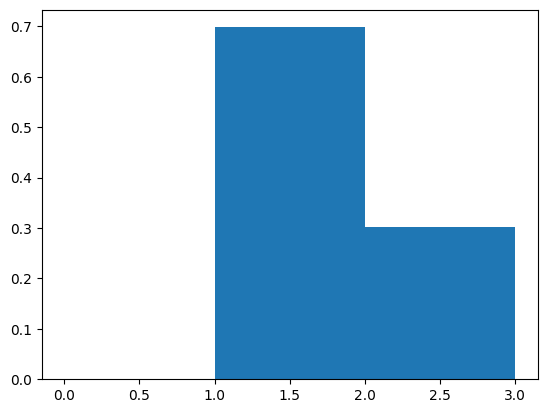

In [9]:
sample_choices =softmax_readouts.argmax(-1)
counts = []
for i in range(64):
    answers = sample_choices[:,i]
    counts.append(len( answers.unique()))

_=plt.hist(counts, density=True, bins=np.arange(0,4), align='mid')

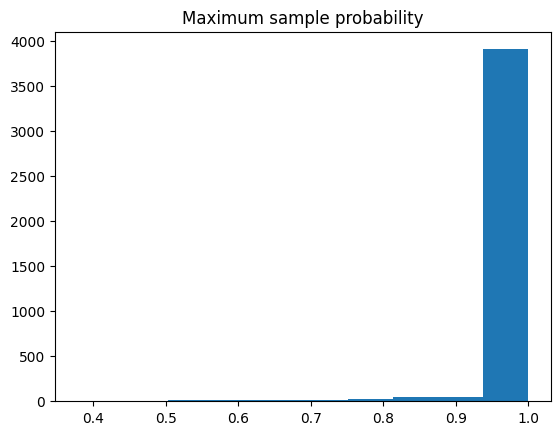

In [113]:
plt.hist(softmax_readouts.max(-1).values.view(-1))
_ = plt.title('Maximum sample probability')

Observations:
1. The sampled logits are mostly very certain, even more so than the target outputs.
    - samples are uniform while targets are not: 22%
      
          {0, 3, 11, 14, 18, 25, 30, 34, 39, 40, 49, 52, 56, 58}
    - non-uniform samples (often not very well aligned): 16%

          {8, 16, 23, 24, 27, 29, 35, 38, 44, 59}
    - samples are very wrong: 17%

          {13, 16, 18, 22, 27, 32, 45, 46, 50, 54, 61}
    - multiple samples aligned well: 3%

          {31, 47}

    - well-aligned single samples: 42%

This is for one sampling, but the behaviors for indidividual runs seem fairly consistent across re-runs


2. Most of the sample that we produce are delta-like: the probability mass is usually concentrated around a single answer.
   - despite this, as observed above, there are several cases where different samples do cover different regions of answer space.
   - these are usually not answers related to the outputs, but...
   - We only see 1-2 best anwsers produced but individual samples. All other variability is internal to the samples

In [116]:
# doing this fairly manually:

frequencies = []
probabilities = []

sample_choices =softmax_readouts.argmax(-1)
output_probs = torch.softmax(outputs.logits, dim=-1)

for batch_ind in range(64):
    values, counts = sample_choices[:,batch_ind].unique(return_counts=True)

    for i in range(len(values)):
        probabilities.append(output_probs[batch_ind, values[i]].item())
        frequencies.append( counts[i].item() / 64)
        

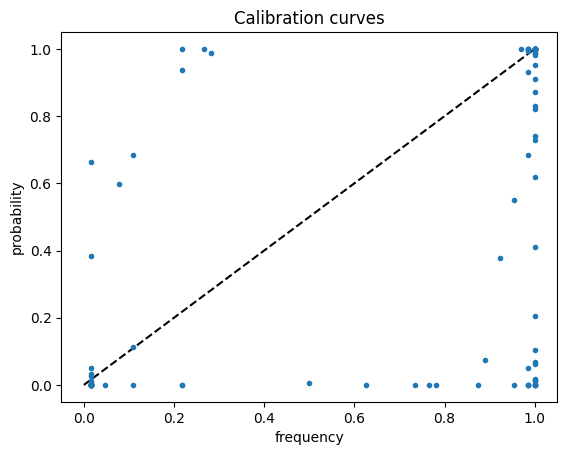

In [117]:
plt.plot(np.linspace(0,1), np.linspace(0,1), '--k')
plt.plot(frequencies, probabilities, '.')
plt.title('Calibration curves')
plt.xlabel('frequency')
_=plt.ylabel('probability')


Yikes, the calibration curve is really no better than before:
- many samples where probability is basically 0
- many 100% frequencies with varying probabilities.


#### Key takeaways:
1. The samples are quite stochastic. They focus on individual answers.
2. They are somewhat accurate.
3. They don't produce calibration-like outputs. This is not terribly surprising given the poor validation performance.


The main thing that I'm taking away from this is the fact that we _can_ indeed learn diverse outputs, but that it remains challenging to achieve good performance from the multiple outputs. A fundamental problem here is that, if our model has high certainty, then the incentive to learn different readouts disappears, so better models give worse calibration signal. This is why we would want the self-calibration signal _while_ learning the classifier outputs: to disincentivize high-certainty wrong answers even more.

#### Next steps:
- More sample would probably help. Better training hyper-parameters, better objective function?
- How important is the calibration?
- How low of temperature do we need, while still achieving a diverse set of outputs?



### Analysis of learned model 2: little temperature annealing

Does significantly better in terms of training and validation errors

In [3]:
from src.train.training import train_readout

dl_train = torch.utils.data.DataLoader(image_datasets['train'], batch_size=64, num_workers=1)
dl_val = torch.utils.data.DataLoader(image_datasets['validation'], batch_size=64, num_workers=1)

In [4]:
from safetensors import safe_open
raw = safe_open('baseline_readout/readout/model.safetensors', framework='pt')
model.model.load_state_dict({key: raw.get_tensor(key) for key in raw.keys()}, strict=False )

_IncompatibleKeys(missing_keys=['dinov2.embeddings.cls_token', 'dinov2.embeddings.mask_token', 'dinov2.embeddings.position_embeddings', 'dinov2.embeddings.patch_embeddings.projection.weight', 'dinov2.embeddings.patch_embeddings.projection.bias', 'dinov2.encoder.layer.0.norm1.weight', 'dinov2.encoder.layer.0.norm1.bias', 'dinov2.encoder.layer.0.attention.attention.query.weight', 'dinov2.encoder.layer.0.attention.attention.query.bias', 'dinov2.encoder.layer.0.attention.attention.key.weight', 'dinov2.encoder.layer.0.attention.attention.key.bias', 'dinov2.encoder.layer.0.attention.attention.value.weight', 'dinov2.encoder.layer.0.attention.attention.value.bias', 'dinov2.encoder.layer.0.attention.output.dense.weight', 'dinov2.encoder.layer.0.attention.output.dense.bias', 'dinov2.encoder.layer.0.layer_scale1.lambda1', 'dinov2.encoder.layer.0.norm2.weight', 'dinov2.encoder.layer.0.norm2.bias', 'dinov2.encoder.layer.0.mlp.fc1.weight', 'dinov2.encoder.layer.0.mlp.fc1.bias', 'dinov2.encoder.layer

In [5]:
from src.model.CLS_token_probing import SecondaryReadouts
ckpt_state = torch.load('slow_temp_annealing_ckpt/epoch=2-step=9200.ckpt', weights_only=False)
readout = SecondaryReadouts(11, temperature=0.1, num_samples=20)
readout.load_state_dict(ckpt_state['state_dict'])
model.add_readout(readout)

In [6]:
batch = next(iter(dl_val))

W0302 10:53:55.175000 50265 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


In [7]:
with torch.no_grad():
    outputs = model.model.forward(batch['input'], output_hidden_states=True)
    model_input = outputs.hidden_states[readout.layer_ind].detach()
    sampled_readouts = torch.stack([readout.decoder.forward(model_input, readout.base_layer)
                                            for i in range(64)
                                            ])
    softmax_readouts = torch.softmax(sampled_readouts / readout.temperature, dim=-1
                                         ).clamp(1E-30)

In [8]:
def plot_sample(batch_ind):
    for i in range(64):
        plt.plot(torch.softmax(outputs.logits, dim=-1)[batch_ind], 'ok')
        plt.plot(softmax_readouts[i, batch_ind, :], '--')

        
    plt.show()

interact(plot_sample, batch_ind=IntSlider(min=0, max=63, step=1, value=0));

interactive(children=(IntSlider(value=0, description='batch_ind', max=63), Output()), _dom_classes=('widget-in…

There appears to be somewhat less output variability

In [9]:
sample_choices =softmax_readouts.argmax(-1)

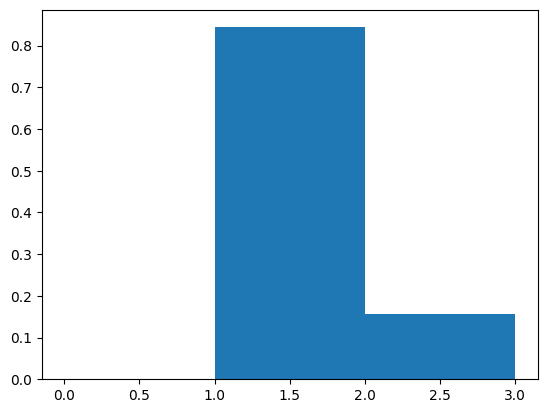

In [10]:
counts = []
for i in range(64):
    answers = sample_choices[:,i]
    counts.append(len( answers.unique()))

_=plt.hist(counts, density=True, bins=np.arange(0,4), align='mid')

Less multiple answers, but, moreover, there seems to be less variability within the individual samples.

In [11]:
# doing this fairly manually:

frequencies = []
probabilities = []

sample_choices =softmax_readouts.argmax(-1)
output_probs = torch.softmax(outputs.logits, dim=-1)

for batch_ind in range(64):
    values, counts = sample_choices[:,batch_ind].unique(return_counts=True)

    for i in range(len(values)):
        probabilities.append(output_probs[batch_ind, values[i]].item())
        frequencies.append( counts[i].item() / 64)
        

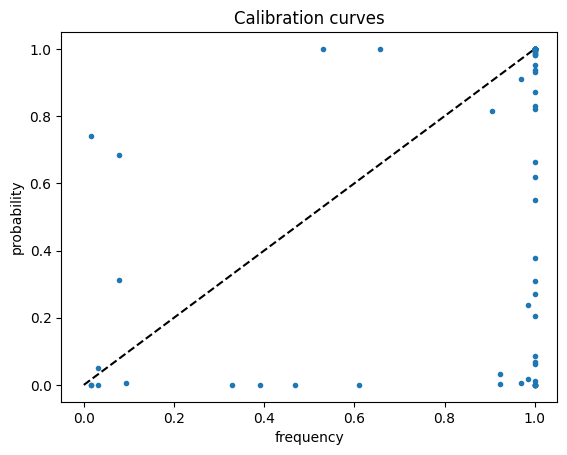

In [12]:
plt.plot(np.linspace(0,1), np.linspace(0,1), '--k')
plt.plot(frequencies, probabilities, '.')
plt.title('Calibration curves')
plt.xlabel('frequency')
_=plt.ylabel('probability')

Calibration curves still suck.

This illuminates that here (as with above) the calibration seems be impacted by calibration failures __within__ the samples themselves. (especially above) The output curves are multi-peaked, but the number of answers is low.

What I wrote previously is actually not correct: we were not (previously) seeing a mixture of delta-like outputs. Rather, individual, multi-peaked outputs.

By eye high temperature and low temperature seem to be about equally 'multi-peaked'. (If anything, low-temp is less delta-like)

#### I'm starting to think that decoding outputs might not be the best way forward.

Previous idea: by extracting multiple independent outputs, we can get a view of how evidence is distributed around the network. The challenge is actually enforcing the 'spread' of decoded outputs, when single readouts are very effective.

Alternatives:
1. Predict CLS token outputs from a random CLS token: re-extract the information that is flowing into the CLS token. Basically, trying to trace the information flow that allows for shuffling robustness.
2. Use multiple decoders, in combination with older ideas like TENT and SHOT. This is where I _was_ trying to go before the self-calibration idea got me excited.

## Needed: better metrics

The previous confusion indicates that we need better metrics to assess the outputs of a given model.

In [2]:
# model setup
from src.model.CLS_token_probing import SelfCalibratingReadout
from src.model.setup import image_model_setup
from src.train.training import train_readout

model_name = "facebook/dinov2-base"
dataset_name = "temp_dataset_subsample"

model, image_datasets, _ = image_model_setup(model_name, dataset_name, 1000)

dl_train = torch.utils.data.DataLoader(image_datasets['train'], batch_size=64, num_workers=1)
dl_val = torch.utils.data.DataLoader(image_datasets['validation'], batch_size=64, num_workers=1)

W0302 18:26:30.480000 1278 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


import error: No module named 'triton'


Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
from safetensors import safe_open
from src.model.CLS_token_probing import SecondaryReadouts

def load_model_with_readouts(readouts, temperature):
    model, _, _ = image_model_setup(model_name, dataset_name, 1000)
    raw = safe_open('baseline_readout/readout/model.safetensors', framework='pt')
    model.model.load_state_dict({key: raw.get_tensor(key) for key in raw.keys()}, strict=False )

    readout = SecondaryReadouts.from_pretrained(readouts, layer_ind=11, temperature=temperature, num_samples=20)
    model.add_readout(readout)
    return model

def get_readout_samples(model, batch):
    """Re-implements part of the readout to get multiple sample outputs"""
    with torch.no_grad():
        outputs = model.model.forward(batch['input'].to(model.device), output_hidden_states=True)
        model_input = outputs.hidden_states[model.readout.layer_ind].detach()
        sampled_readouts = torch.stack([model.readout.decoder.forward(model_input, model.readout.base_layer)
                                                for i in range(50)
                                                ])

    return sampled_readouts
        

In [4]:
from torch.distributions import Categorical

def entropy(samples):
    probs = torch.softmax(samples, dim=-1)
    dist = Categorical(probs=probs)
    entropy = dist.entropy()

    return entropy
    
def entropy_stats(model, dl):
    sample_entropies = []
    mean_entropies = []

    for batch in tqdm(dl):
        samples = get_readout_samples(model, batch)
        sample_entropies.append( entropy(samples).mean(0) )
        mean_entropies.append( entropy( samples.mean(0)) )

    return torch.concat(sample_entropies).mean().item(), torch.concat(mean_entropies).mean().item()

In [5]:
model = load_model_with_readouts('KL_slow_annealing/readout/', temperature=1.0)
model = model.to('mps')
sample_slow, mean_slow = entropy_stats(model, dl_val)

Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading weights from local directory


0it [00:00, ?it/s]W0302 18:26:39.357000 1283 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
782it [33:50,  2.05s/it]

import error: No module named 'triton'


782it [33:51,  2.60s/it]


In [6]:
model = load_model_with_readouts('KL_test/readout/', temperature=1.0)
model = model.to('mps')
sample_low, mean_low = entropy_stats(model, dl_val)

Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading weights from local directory


0it [00:00, ?it/s]W0302 19:00:31.570000 1669 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
782it [38:08,  2.40s/it]

import error: No module named 'triton'


782it [38:09,  2.93s/it]


Of course, the individual sample entropy is strongly dependent on the temperature. The difference between these two tells us how much the samples vary vs having variance within the samples. My null expectation is that lower training temperatures should lead to more between sample variance.

In [7]:
print('Low temperature training: ', sample_low, mean_low)
print('High temperature training: ', sample_slow, mean_slow)


Low temperature training:  0.24635162949562073 0.2427964210510254

High temperature training:  0.24941405653953552 0.24865466356277466

This show what I thought the above results were showing, which is the opposite of my expectation (although pretty minor).
- Low temperature training -> lower entropies overall
- Low temperature training -> greater gap between average entropy of samples and entropy of averages
- Low temperatures -> more of the variability is _within_ individual samples, less between samples